In [6]:
import os

In [5]:
os.listdir('/kaggle/input/competitions/store-sales-time-series-forecasting')

['oil.csv',
 'sample_submission.csv',
 'holidays_events.csv',
 'stores.csv',
 'train.csv',
 'test.csv',
 'transactions.csv']

In [2]:
import pandas as pd
train = pd.read_csv("/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv")
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [3]:
train.shape

(3000888, 6)

In [4]:
train.dtypes

id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
dtype: object

In [5]:
train['date'] = pd.to_datetime(train['date'])
train.dtypes

id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object

In [6]:
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [7]:
train.describe()

,id,date,store_nbr,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01


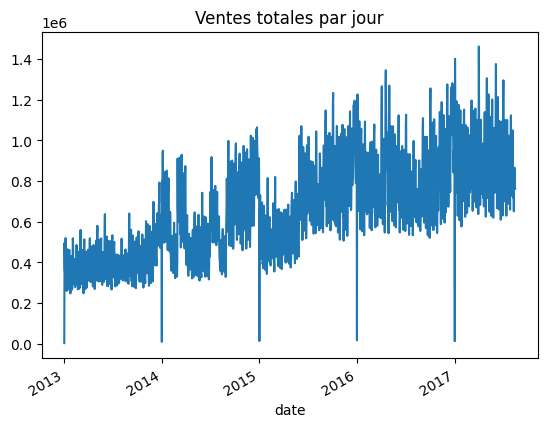

In [10]:
import matplotlib.pyplot as plt

daily_sales = train.groupby('date')['sales'].sum()

daily_sales.plot()
plt.title("Ventes totales par jour")
plt.show()

In [11]:
store1 = train[train['store_nbr'] == 1]
store1.shape

(55572, 6)

In [13]:
store1_daily = store1.groupby('date')['sales'].sum()
store1_daily.head()

date
2013-01-01       0.000000
2013-01-02    7417.148000
2013-01-03    5873.244001
2013-01-04    5919.879001
2013-01-05    6318.785010
Name: sales, dtype: float64

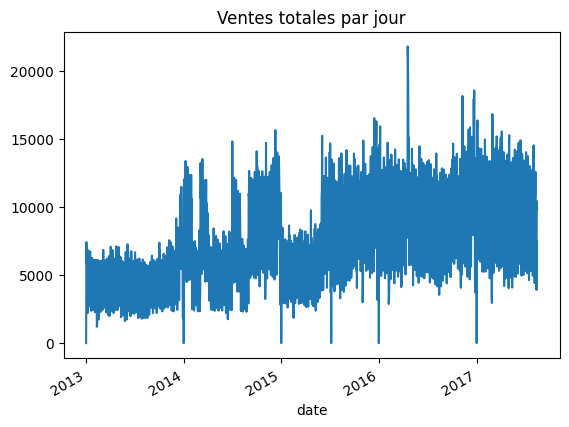

In [14]:
store1_daily.plot()
plt.title("Ventes totales par jour")
plt.show()

In [15]:
!pip install prophet

In [16]:
df_prophet = store1_daily.reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet.head()

,ds,y
0,2013-01-01,0.000000
1,2013-01-02,7417.148000
2,2013-01-03,5873.244001
3,2013-01-04,5919.879001
4,2013-01-05,6318.785010


In [17]:
train_prophet = df_prophet[:-90]
test_prophet = df_prophet[-90:]

print(train_prophet.shape)
print(test_prophet.shape)

(1594, 2)
(90, 2)


In [18]:
from prophet import Prophet

model = Prophet()
model.fit(train_prophet)

07:43:03 - cmdstanpy - INFO - Chain [1] start processing
07:43:04 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1679,2017-08-11,11123.423345,8824.252496,13441.195844
1680,2017-08-12,10472.276960,8153.531828,12777.527788
1681,2017-08-13,5562.793739,3368.718687,7957.549989
1682,2017-08-14,10359.711405,8019.727416,12731.782556
1683,2017-08-15,10201.406555,8054.326479,12531.812897


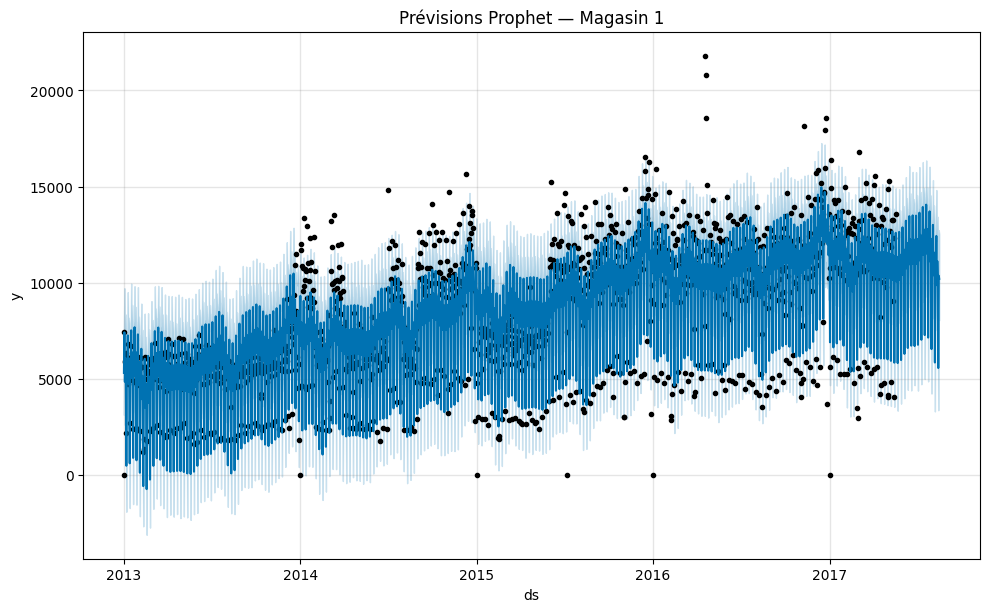

In [21]:
model.plot(forecast)
plt.title("Prévisions Prophet — Magasin 1")
plt.show()

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = test_prophet['y'].values
y_pred = forecast[-90:]['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 1044.06
RMSE: 1403.38


In [23]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(store1_daily)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"P-value: {result[1]:.4f}")

ADF Statistic: -2.9802
P-value: 0.0368


In [24]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(store1_daily, order=(5,1,0))
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1684
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -15735.177
Date:                Wed, 03 Jun 2026   AIC                          31482.354
Time:                        07:51:53   BIC                          31514.924
Sample:                             0   HQIC                         31494.417
                               - 1684                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7152      0.027    -26.872      0.000      -0.767      -0.663
ar.L2         -0.4696      0.028    -16.697      0.000      -0.525      -0.415
ar.L3         -0.4436      0.027    -16.349      0.0

In [25]:
forecast_arima = model_arima_fit.forecast(steps=90)
print(forecast_arima)

1684    8894.131010
1685    8056.613985
1686    7339.435050
1687    7752.477789
1688    8652.779967
           ...     
1769    8273.257194
1770    8273.257196
1771    8273.257199
1772    8273.257200
1773    8273.257199
Name: predicted_mean, Length: 90, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [26]:
y_true_arima = test_prophet['y'].values
y_pred_arima = forecast_arima.values

mae_arima = mean_absolute_error(y_true_arima, y_pred_arima)
rmse_arima = np.sqrt(mean_squared_error(y_true_arima, y_pred_arima))

print(f"ARIMA MAE: {mae_arima:.2f}")
print(f"ARIMA RMSE: {rmse_arima:.2f}")

ARIMA MAE: 3323.57
ARIMA RMSE: 3572.53


In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(store1_daily.values.reshape(-1, 1))
print(scaled_data[:5])

[[0.        ]
 [0.34040947]
 [0.26955211]
 [0.27169242]
 [0.29000018]]


In [28]:
import numpy as np

def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)
print(X.shape, y.shape)

(1624, 60, 1) (1624, 1)


In [29]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, X_test.shape)

(1299, 60, 1) (325, 60, 1)


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(60, 1)))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

2026-06-03 08:00:35.312701: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780473635.521146      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780473635.573650      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780473636.041661      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780473636.041694      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780473636.041697      58 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model_lstm.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0482 - val_loss: 0.0242
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0140 - val_loss: 0.0219
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0139 - val_loss: 0.0229
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0139 - val_loss: 0.0216
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0138 - val_loss: 0.0216
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0137 - val_loss: 0.0221
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0140 - val_loss: 0.0262
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0140 - val_loss: 0.0230
Epoch 9/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0138 - val_loss: 0.0218
Epoch 10/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0136 - val_loss: 0.0218
Epoch 11/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0136 - val_loss: 0.0214
Epoch 12/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0

In [32]:
y_pred_lstm = model_lstm.predict(X_test)

y_pred_lstm = scaler.inverse_transform(y_pred_lstm)
y_test_lstm = scaler.inverse_transform(y_test)

mae_lstm = mean_absolute_error(y_test_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))

print(f"LSTM MAE: {mae_lstm:.2f}")
print(f"LSTM RMSE: {rmse_lstm:.2f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
LSTM MAE: 2311.52
LSTM RMSE: 3176.47


ValueError: x and y must have same first dimension, but have shapes (90,) and (325, 1)

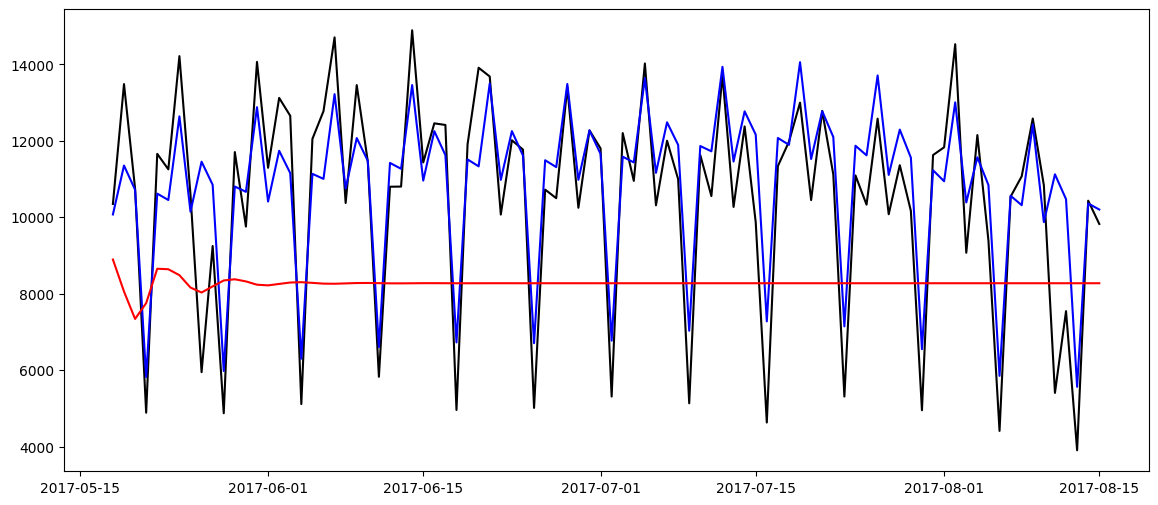

In [33]:
plt.figure(figsize=(14, 6))

# Vraies valeurs
plt.plot(test_prophet['ds'].values, test_prophet['y'].values, 
         label='Vraies valeurs', color='black')

# Prophet
plt.plot(test_prophet['ds'].values, forecast[-90:]['yhat'].values, 
         label='Prophet', color='blue')

# ARIMA
plt.plot(test_prophet['ds'].values, forecast_arima.values, 
         label='ARIMA', color='red')

# LSTM
plt.plot(test_prophet['ds'].values, y_pred_lstm, 
         label='LSTM', color='green')

plt.title("Comparaison des 3 modèles — Magasin 1")
plt.legend()
plt.show()